# IPCA x Câmbio USD/BRL x Selic — Banco Central do Brasil (SGS)

Coleta e análise exploratória de três indicadores macroeconômicos brasileiros via API do Banco Central (SGS - Sistema Gerenciador de Séries Temporais):

- **IPCA** (série 433) — variação mensal, %
- **Câmbio USD/BRL** (série 1) — venda, diário
- **Selic meta** (série 432) — % a.a., definida pelo Copom

Período: desde 01/01/2020.

## 1. Coleta dos dados

In [1]:
from pathlib import Path
from bcb import sgs
import pandas as pd

# Códigos de série do SGS/Banco Central (https://www3.bcb.gov.br/sgspub)
SERIE_IPCA = 433        # IPCA - variação mensal (%)
SERIE_CAMBIO = 1        # Câmbio USD/BRL - venda, diário
SERIE_SELIC = 432       # Selic meta (% a.a.), definida pelo Copom
DATA_INICIO = "2020-01-01"

# Assume que o notebook é executado a partir de notebooks/ (padrão do Jupyter/VS Code)
OUTPUTS_DIR = Path.cwd().parent / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

df = sgs.get(
    {"ipca": SERIE_IPCA, "cambio": SERIE_CAMBIO, "selic_meta": SERIE_SELIC},
    start=DATA_INICIO,
)
df.head()

,ipca,cambio,selic_meta
Date,,,
2020-01-01,0.21,NaN,4.5
2020-01-02,NaN,4.0213,4.5
2020-01-03,NaN,4.0522,4.5
2020-01-04,NaN,NaN,4.5
2020-01-05,NaN,NaN,4.5


## 2. Exploração

In [2]:
df.describe()

,ipca,cambio,selic_meta
count,78.000000,1638.000000,2386.000000
mean,0.467949,5.272405,10.170893
std,0.414551,0.340309,4.617395
min,-0.680000,4.021300,2.000000
25%,0.240000,5.057900,5.250000
50%,0.435000,5.268000,11.750000
75%,0.707500,5.496375,13.750000
max,1.620000,6.208600,15.000000


In [3]:
df.tail()

,ipca,cambio,selic_meta
Date,,,
2026-07-09,NaN,5.1329,14.25
2026-07-10,NaN,5.1088,14.25
2026-07-11,NaN,NaN,14.25
2026-07-12,NaN,NaN,14.25
2026-07-13,NaN,5.1183,14.25


## 3. Visualização

IPCA, câmbio e Selic têm granularidades diferentes (mensal, diário e
"eventos" a cada reunião do Copom). Para comparar as três, câmbio e Selic
são reamostrados para o fim de cada mês: câmbio pela média
(`resample("ME").mean()`) e Selic pelo último valor vigente no mês
(`resample("ME").last()`), já que a meta fica constante entre reuniões.

IPCA e câmbio ficam no mesmo painel, em eixo duplo (facilita ver quem se
move primeiro). A Selic fica num painel abaixo, com eixo X compartilhado —
ela é uma série em degraus, então misturá-la no mesmo eixo das outras
duas polui a leitura.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


def plot_ipca_cambio_selic(ipca, cambio, selic, titulo, output_path):
    """IPCA e câmbio em eixo duplo (painel de cima); Selic em painel abaixo, eixo X comum."""
    fig, (ax_topo, ax_selic) = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )

    ax_topo.plot(ipca.index, ipca, color="tab:red", label="IPCA (% mensal)")
    ax_topo.set_ylabel("IPCA (% mensal)", color="tab:red")
    ax_topo.tick_params(axis="y", labelcolor="tab:red")

    ax_cambio = ax_topo.twinx()
    ax_cambio.plot(cambio.index, cambio, color="tab:blue", label="Câmbio USD/BRL (venda)")
    ax_cambio.set_ylabel("Câmbio USD/BRL (venda)", color="tab:blue")
    ax_cambio.tick_params(axis="y", labelcolor="tab:blue")

    ax_selic.plot(selic.index, selic, color="tab:green")
    ax_selic.set_ylabel("Selic meta (% a.a.)", color="tab:green")
    ax_selic.set_xlabel("Data")
    ax_selic.grid(True, alpha=0.3)

    fig.suptitle(titulo)
    fig.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

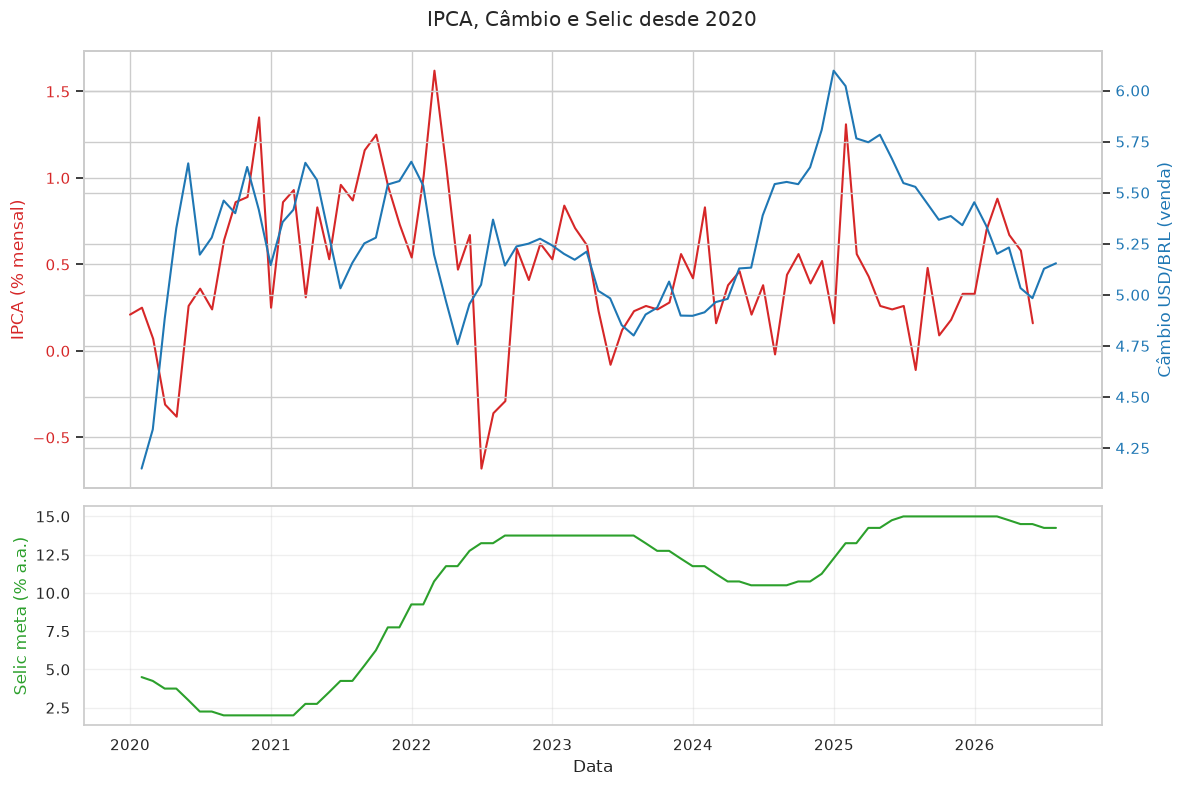

In [5]:
ipca_mensal = df["ipca"].dropna()
cambio_mensal = df["cambio"].resample("ME").mean()
selic_mensal = df["selic_meta"].resample("ME").last()

plot_ipca_cambio_selic(
    ipca_mensal,
    cambio_mensal,
    selic_mensal,
    "IPCA, Câmbio e Selic desde 2020",
    OUTPUTS_DIR / "grafico-ipca-cambio.png",
)

## 4. Verificação factual dos números citados nos insights

Antes de escrever conclusões, vale conferir se os números citados abaixo
batem com os dados reais (a fonte de verdade é sempre o `df`, nunca a
memória de quem escreveu o texto).

In [6]:
# IPCA: maiores picos (confirmar 1,62% mar/2022 e a posição de 1,31% fev/2025 no ranking)
print("Top 5 IPCA:")
print(df["ipca"].nlargest(5))
print()

# IPCA: valores negativos de 2020 (confirmar abr e mai/2020)
print("IPCA negativo em 2020:")
print(df.loc["2020", "ipca"][df.loc["2020", "ipca"] < 0])
print()

# Câmbio: extremos globais e por período
print("Câmbio máximo:", round(df["cambio"].max(), 2), "em", df["cambio"].idxmax().date())
print("Câmbio mínimo (2022 em diante):", round(df.loc["2022":, "cambio"].min(), 2),
      "em", df.loc["2022":, "cambio"].idxmin().date())
print()

# Selic: confirmar mínima de 2% e quanto tempo ficou em 13,75% em 2023
print("Selic mínima:", df["selic_meta"].min())
print("Selic em 2023 (valores únicos):", sorted(df.loc["2023", "selic_meta"].dropna().unique()))
print("Selic em 2023 (por mês):")
print(df.loc["2023", "selic_meta"].resample("MS").last().dropna())

Top 5 IPCA:
Date
2022-03-01    1.62
2020-12-01    1.35
2025-02-01    1.31
2021-10-01    1.25
2021-09-01    1.16
Name: ipca, dtype: float64

IPCA negativo em 2020:
Date
2020-04-01   -0.31
2020-05-01   -0.38
Name: ipca, dtype: float64

Câmbio máximo: 6.21 em 2025-01-02
Câmbio mínimo (2022 em diante): 4.62 em 2022-04-04

Selic mínima: 2.0
Selic em 2023 (valores únicos): [np.float64(11.75), np.float64(12.25), np.float64(12.75), np.float64(13.25), np.float64(13.75)]
Selic em 2023 (por mês):
Date
2023-01-01    13.75
2023-02-01    13.75
2023-03-01    13.75
2023-04-01    13.75
2023-05-01    13.75
2023-06-01    13.75
2023-07-01    13.75
2023-08-01    13.25
2023-09-01    12.75
2023-10-01    12.75
2023-11-01    12.25
2023-12-01    11.75
Freq: MS, Name: selic_meta, dtype: float64


## 5. Insights

> Nota metodológica: as observações abaixo descrevem padrões temporais entre as
> séries (ordem em que se movem, defasagens). Correlação temporal não prova
> causalidade: os movimentos são compatíveis com as explicações discutidas, mas
> não as confirmam isoladamente. As leituras econômicas servem como hipóteses e
> pontos de partida para investigação, não como conclusões cravadas.

1. **A inflação alta de 2021 até o início de 2022 veio depois de uma combinação
   de fatores.** Em 2020, o Banco Central baixou muito os juros (Selic caiu pra
   2%, a menor da história) e o governo colocou bastante dinheiro na economia
   por causa da pandemia (estímulo fiscal). Vale separar os dois: Selic baixa é
   política monetária, o auxílio/gasto público é política fiscal. O efeito não
   apareceu na inflação na hora: em abril e maio de 2020 o IPCA até ficou
   negativo (-0,31% e -0,38%). Ao longo de 2021 o IPCA foi subindo mês a mês,
   até estourar em 1,62% em março de 2022 (o maior valor da série). A defasagem
   entre o estímulo de 2020 e a aceleração da inflação chama atenção. Importante:
   os dados aqui não permitem isolar o quanto veio de política monetária/fiscal
   versus choques de oferta pós-pandemia e alta de commodities. Todos esses
   fatores foram apontados por economistas no período.

2. **O câmbio se moveu antes da inflação nas duas grandes altas.** Na pandemia
   (2020-2021), o dólar subiu até uns R\$5,65, e a inflação forte só veio depois,
   ao longo de 2021 até março de 2022. Depois disso, o dólar caiu até uma mínima
   de R\$4,62 no início de abril de 2022, subiu rápido até R\$5,48 em julho do
   mesmo ano, ficou andando de lado entre R\$5,0 e R\$5,4 até fevereiro de 2023, e
   só então caiu de novo até uma mínima de R\$4,73-4,85 em meados de 2023. A
   partir do início de 2024 ele disparou outra vez, batendo o pico de R\$6,10 na
   virada pra 2025. De novo, poucos meses depois, em fevereiro de 2025, o IPCA
   deu um salto pra 1,31% (o terceiro maior valor da série, atrás de março/2022
   e dezembro/2020). Nas duas grandes subidas, 2020-21 e 2024-25, o câmbio se
   moveu primeiro. Ressalva: câmbio e inflação se influenciam nos dois sentidos
   (dólar caro encarece importados e pressiona preços; mas inflação e
   expectativas também afetam o câmbio), então a ordem temporal é uma pista para
   investigar, não prova de que um causa o outro.

3. **O IPCA mais baixo desde 2023 conviveu com Selic alta.** Depois do pico de
   março de 2022, a inflação começou a cair (de forma bem instável) ainda em
   meados de 2022, e só realmente se estabilizou numa faixa baixa a partir do
   início de 2023. Isso aconteceu enquanto a Selic ficou lá em cima, em 13,75%
   de janeiro a julho de 2023, caindo aos poucos dali em diante (13,25% em
   agosto, até 11,75% em dezembro). Os dados sugerem que a estabilidade da
   inflação convive com juro alto, uma relação coerente com o que se espera da
   política monetária, ainda que o gráfico sozinho não meça essa contribuição.
   Além disso, o câmbio voltou a subir forte a partir de 2024, batendo R\$6,10
   no fim do ano, sinal de que as pressões não desapareceram. E juro alto por
   período prolongado tem seu próprio custo, sobretudo sobre a dívida pública.